# Notebook 6: Sensitivity Analysis & Validity of Assumptions

## When do these models work? Parameter ranges and breakdown conditions.

This notebook systematically explores the parameter space where the theoretical models 
used in dv/v interpretation remain valid, and identifies conditions where assumptions break down.

### References
All project papers: Okubo et al. (2024), Clements & Denolle (2023), Ermert et al. (2023), 
Richter et al. (2014), Fokker et al. (2021), Tromp & Trampert (2018), Murnaghan (1937).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from disba import PhaseSensitivity

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'figure.dpi': 150,
    'font.family': 'serif', 'mathtext.fontset': 'cm',
    'axes.grid': True, 'grid.alpha': 0.3
})
print("Environment ready.")
print("Note: first call to disba will trigger numba JIT compilation (~5-10 s).")


Environment ready.
Note: first call to disba will trigger numba JIT compilation (~5-10 s).


## 1. Assumption: Homogeneous Half-Space

The Berger (1975) thermoelastic and Roeloffs (1988) poroelastic solutions assume 
a **homogeneous half-space**. Real geology is layered, and the dv/v measurement
is depth-averaged by surface-wave sensitivity kernels.

**When does this break down?**
- When velocity contrasts are strong (e.g., soft sediment over bedrock)
- When measurement frequency implies sensitivity deeper than the homogeneous layer
- Ermert et al. (2023) use station-specific velocity profiles and sensitivity kernels


In [ ]:
# === Sensitivity Kernel via disba (PhaseSensitivity) ===
#
# Velocity model: representative near-surface profile for shallow ambient-noise
# monitoring (consistent with California/Parkfield shallow crust).
# Format: [thickness_km, Vp_km/s, Vs_km/s, density_g/cm3]
# Last row is the half-space (thickness ignored by disba).
#
# Substitute your own site model here -- all downstream figures update automatically.

VELOCITY_MODEL_KM = np.array([
    [0.05,  0.40,  0.20,  1.80],   # Soft sediment / soil
    [0.10,  0.80,  0.40,  1.90],   # Consolidated sediment
    [0.30,  1.50,  0.80,  2.10],   # Shallow fractured crust
    [0.50,  3.00,  1.50,  2.40],   # Competent rock
    [20.0,  6.00,  3.50,  2.70],   # Half-space
])

# Cumulative layer bottom depths in metres (for plotting layer boundaries)
thicknesses_m = VELOCITY_MODEL_KM[:-1, 0] * 1000          # exclude half-space
LAYER_DEPTHS_M = np.cumsum(thicknesses_m)                  # [50, 150, 450, 950] m

# Vs at each layer for the Panel (b) legend
VS_LAYER_KMS = VELOCITY_MODEL_KM[:, 2]                     # km/s array


def refine_model(velocity_model_km, sub_km=0.02, halfspace_depth_km=15.0, halfspace_sub_km=0.2):
    """
    Subdivide a layered model into thin sub-layers for smooth kernel computation.
    Each finite-thickness layer is split into sub-layers of ~sub_km thickness (20 m default).
    The half-space is sampled to halfspace_depth_km with coarser spacing.

    Parameters
    ----------
    velocity_model_km : np.ndarray, shape (N, 4)
        Input model [thickness_km, Vp, Vs, rho]. Last row = half-space.
    sub_km : float
        Target sub-layer thickness in km (default 0.02 = 20 m).
    halfspace_depth_km : float
        Total depth to which to sample the half-space (default 15 km).
    halfspace_sub_km : float
        Sub-layer thickness for the half-space sampling (default 0.2 km).

    Returns
    -------
    refined : np.ndarray, shape (M, 4)
        Refined model. Last row is still the half-space.
    """
    layers = []
    for row in velocity_model_km[:-1]:
        thk_km, vp, vs, rho = row
        n_sub = max(1, int(np.round(thk_km / sub_km)))
        sub_thk = thk_km / n_sub
        for _ in range(n_sub):
            layers.append([sub_thk, vp, vs, rho])
    # Sample half-space to halfspace_depth_km
    hs = velocity_model_km[-1]
    n_hs = max(1, int(np.round(halfspace_depth_km / halfspace_sub_km)))
    hs_thk = halfspace_depth_km / n_hs
    for _ in range(n_hs):
        layers.append([hs_thk, hs[1], hs[2], hs[3]])
    # Final half-space row (required by disba)
    layers.append([hs[0], hs[1], hs[2], hs[3]])
    return np.array(layers)


REFINED_MODEL_KM = refine_model(VELOCITY_MODEL_KM)  # ~120 sub-layers
print(f"Refined model: {len(REFINED_MODEL_KM)} layers (last = half-space)")


def rayleigh_vs_kernel(velocity_model_km, frequency_hz):
    """
    Compute the Rayleigh-wave fundamental-mode phase velocity sensitivity
    kernel with respect to Vs at a given frequency using disba.

    Parameters
    ----------
    velocity_model_km : np.ndarray, shape (N, 4)
        Layered model [thickness_km, Vp_km/s, Vs_km/s, density_g/cm3].
    frequency_hz : float
        Measurement frequency in Hz. Converted to period internally.

    Returns
    -------
    depth_m : np.ndarray
        Layer mid-point depths in metres.
    kernel_norm : np.ndarray
        Vs sensitivity kernel, normalized to peak = 1.
        Returns None, None if disba cannot compute at this period.
    """
    period_s = 1.0 / frequency_hz
    try:
        ps = PhaseSensitivity(*velocity_model_km.T)
        result = ps(period_s, mode=0, wave="rayleigh", parameter="velocity_s")
        depth_m = result.depth * 1000.0          # km -> m
        kernel = np.abs(result.kernel)
        if kernel.max() == 0:
            return None, None
        kernel_norm = kernel / kernel.max()
        return depth_m, kernel_norm
    except Exception:
        return None, None


def centroid_depth_m(velocity_model_km, frequency_hz):
    """Depth-weighted mean of |Vs kernel| in metres."""
    depth_m, kernel = rayleigh_vs_kernel(velocity_model_km, frequency_hz)
    if depth_m is None:
        return np.nan
    return np.sum(depth_m * kernel) / np.sum(kernel)


def vs_step_profile(velocity_model_km, max_depth_km=10.0):
    """
    Build matched-length (depth, Vs) arrays tracing the step-function velocity profile.

    For each layer, emits two points at the same Vs value: one at the top and one
    at the bottom of the layer. Adjacent layers share the boundary depth with
    different Vs values, creating a vertical step. The half-space extends to
    max_depth_km.

    Parameters
    ----------
    velocity_model_km : np.ndarray, shape (N, 4)
        Layered model [thickness_km, Vp_km/s, Vs_km/s, density_g/cm3].
    max_depth_km : float
        Maximum depth to extend the half-space profile (default 10 km).

    Returns
    -------
    depth_m : np.ndarray  -- depths in metres (step function)
    vs_ms   : np.ndarray  -- Vs in m/s (step function)
    Both arrays have equal length.
    """
    depths = []
    vs_vals = []
    d = 0.0  # current layer top in km
    for thk, _, vs, _ in velocity_model_km[:-1]:
        depths.append(d)           # top of layer
        vs_vals.append(vs)
        d += thk
        depths.append(d)           # bottom of layer (= top of next)
        vs_vals.append(vs)
    # Half-space from last boundary to max_depth_km
    hs_vs = velocity_model_km[-1, 2]
    depths.append(d)
    vs_vals.append(hs_vs)
    depths.append(max_depth_km)
    vs_vals.append(hs_vs)
    return np.array(depths) * 1000.0, np.array(vs_vals) * 1000.0  # -> m, m/s


# ---- Build figure -----------------------------------------------------------
frequencies = [0.5, 1.0, 2.0, 4.0, 8.0]   # Hz -- covers ~25 m to ~2 km depth

fig, axes = plt.subplots(1, 3, figsize=(16, 7))

# ---- Panel (a): Vs sensitivity kernels from disba --------------------------
ax = axes[0]

for f in frequencies:
    depth_m, kernel = rayleigh_vs_kernel(REFINED_MODEL_KM, f)
    if depth_m is not None:
        ax.plot(kernel, depth_m, lw=2, label=f'{f} Hz')

# Mark real layer boundaries
for d in LAYER_DEPTHS_M:
    ax.axhline(d, color='red', ls='--', alpha=0.5, lw=1)
ax.text(0.55, LAYER_DEPTHS_M[0] + 15, f'Sed/Crust ({LAYER_DEPTHS_M[0]:.0f} m)',
        color='red', fontsize=8)
ax.text(0.55, LAYER_DEPTHS_M[1] + 15, f'Consol. ({LAYER_DEPTHS_M[1]:.0f} m)',
        color='red', fontsize=8)
ax.text(0.55, LAYER_DEPTHS_M[2] + 15, f'Fract. rock ({LAYER_DEPTHS_M[2]:.0f} m)',
        color='red', fontsize=8)
ax.text(0.55, LAYER_DEPTHS_M[3] + 15, f'Comp. rock ({LAYER_DEPTHS_M[3]:.0f} m)',
        color='red', fontsize=8)

ax.set_xlabel('Vs sensitivity [normalized]')
ax.set_ylabel('Depth [m]')
ax.set_title('(a) Rayleigh-wave Vs sensitivity kernels\n(disba, fundamental mode)')
ax.legend(fontsize=9, loc='lower right')

# -- Vs(z) profile on twin top x-axis ----------------------------------------
depth_vs, vs_ms = vs_step_profile(VELOCITY_MODEL_KM, max_depth_km=2.0)
# Verify matched lengths before plotting
assert len(depth_vs) == len(vs_ms), f"Array mismatch: {len(depth_vs)} vs {len(vs_ms)}"

ax2 = ax.twiny()
ax2.set_autoscaley_on(False)   # prevent twiny auto-scaling from clobbering ylim
ax2.plot(vs_ms, depth_vs, color='grey', lw=2, ls='-', alpha=0.7)
ax2.set_xlabel('Vs [m/s]', color='grey', fontsize=10)
ax2.tick_params(axis='x', colors='grey', labelsize=9)
ax2.set_xlim(0, 4500)
ax2.set_xticks([0, 1000, 2000, 3000, 4000])

# Set y-axis to 10 km AFTER all Panel (a) plotting (last call wins)
axes[0].set_ylim(2000, 0)

# ---- Panel (b): centroid depth vs frequency (disba) vs lambda/3 rule -------
ax = axes[1]
freq_range = np.logspace(-0.5, 0.7, 40)   # 0.3-5 Hz, coarse for speed

# disba centroid depths
centroid_depths = np.array([centroid_depth_m(REFINED_MODEL_KM, f) for f in freq_range])
ax.loglog(freq_range, centroid_depths, 'ko-', lw=2, ms=4,
          label='disba centroid depth')

# lambda/3 rule: use layer-representative Vs (harmonic mean, weighted by layer thickness)
thk = VELOCITY_MODEL_KM[:-1, 0]              # km
vs  = VELOCITY_MODEL_KM[:-1, 2]              # km/s
vs_harmonic = np.sum(thk) / np.sum(thk / vs)  # harmonic mean Vs in km/s
for Vs_val_kms, label, ls in [
        (VELOCITY_MODEL_KM[0, 2], f'Vs={VELOCITY_MODEL_KM[0,2]*1000:.0f} m/s (surface)', ':'),
        (vs_harmonic,              f'Vs={vs_harmonic*1000:.0f} m/s (harmonic mean)', '--'),
]:
    depth_rule = Vs_val_kms * 1000 / freq_range / 3
    ax.loglog(freq_range, depth_rule, lw=1.5, ls=ls, label=f'lambda/3, {label}')

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Centroid sensitivity depth [m]')
ax.set_title('(b) Measurement depth vs frequency\n(disba centroid vs lambda/3 rule)')
ax.legend(fontsize=20)
ax.set_xlim(freq_range[0], freq_range[-1])

# ---- Panel (c): Error from homogeneous-half-space assumption ----------------
# Real comparison built from the disba Vs kernels of Panel (a).
#
# Setup: suppose the *true* fractional Vs perturbation is localized to depths
# shallower than some depth z_pert (e.g. a shallow thermoelastic/hydrological
# layer), with uniform amplitude dVs/Vs = 1 there and 0 below.
#
#   The correctly measured dv/v is the kernel-weighted average:
#       dvv_true(z_pert, f) = sum_{z<z_pert} K(z,f) / sum_z K(z,f)
#
#   A naive "homogeneous half-space" interpretation assumes the velocity
#   perturbation is uniform over the *whole* sampled column, so it would report
#   dvv_homog = 1 regardless of where the perturbation actually sits.
#
#   Relative error of the homogeneous assumption:
#       error = (dvv_homog - dvv_true) / dvv_true * 100%
#
# This uses the SAME disba kernels K(z,f) computed in Panel (a) -- no magic numbers.
ax = axes[2]

z_pert_m = np.linspace(20, 800, 60)   # depth above which the perturbation lives [m]
for f in frequencies:
    depth_m, kernel = rayleigh_vs_kernel(REFINED_MODEL_KM, f)
    if depth_m is None:
        continue
    ktot = np.sum(kernel)
    err = []
    for zp in z_pert_m:
        frac_in = np.sum(kernel[depth_m <= zp]) / ktot   # = dvv_true (dvv_homog=1)
        if frac_in <= 0:
            err.append(np.nan)
        else:
            err.append((1.0 - frac_in) / frac_in * 100.0)
    ax.plot(z_pert_m, err, lw=2, label=f'{f} Hz')

ax.axhline(10, color='gray', ls=':', lw=1)
ax.axhline(25, color='gray', ls=':', lw=1)
ax.set_yscale('log')
ax.set_ylim(1, 1e3)
ax.set_xlabel('Depth extent of true perturbation $z_{pert}$ [m]')
ax.set_ylabel('Relative error of homogeneous assumption [%]')
ax.set_title('(c) Error from homogeneous assumption\n(from disba kernels, Panel a)')
ax.legend(fontsize=9)

fig.suptitle('Validity of Homogeneous Half-Space Assumption', fontsize=20, y=1.02)
plt.tight_layout()

# Re-enforce Panel (a) ylim after tight_layout (which can reset it)
axes[0].set_ylim(2000, 0)

plt.savefig('../figures/notebooks/fig15_homogeneous_validity.png', bbox_inches='tight')
plt.show()


## 2. Assumption: Linear Nonlinear Elasticity ($dv/v = \beta\epsilon_{kk}$)

The acoustoelastic relation $dv/v = \beta\epsilon_{kk}$ assumes:
1. Strain is small enough for the first-order expansion to hold
2. $\beta$ is constant (no strain-dependent $\beta$)
3. No hysteretic or mesoscopic nonlinearity

**Breakdown conditions:**
- Strains > $10^{-5}$: higher-order terms become significant
- Near damage threshold: cracks nucleate/coalesce
- Dynamic loading: rate-dependent effects (slow dynamics)


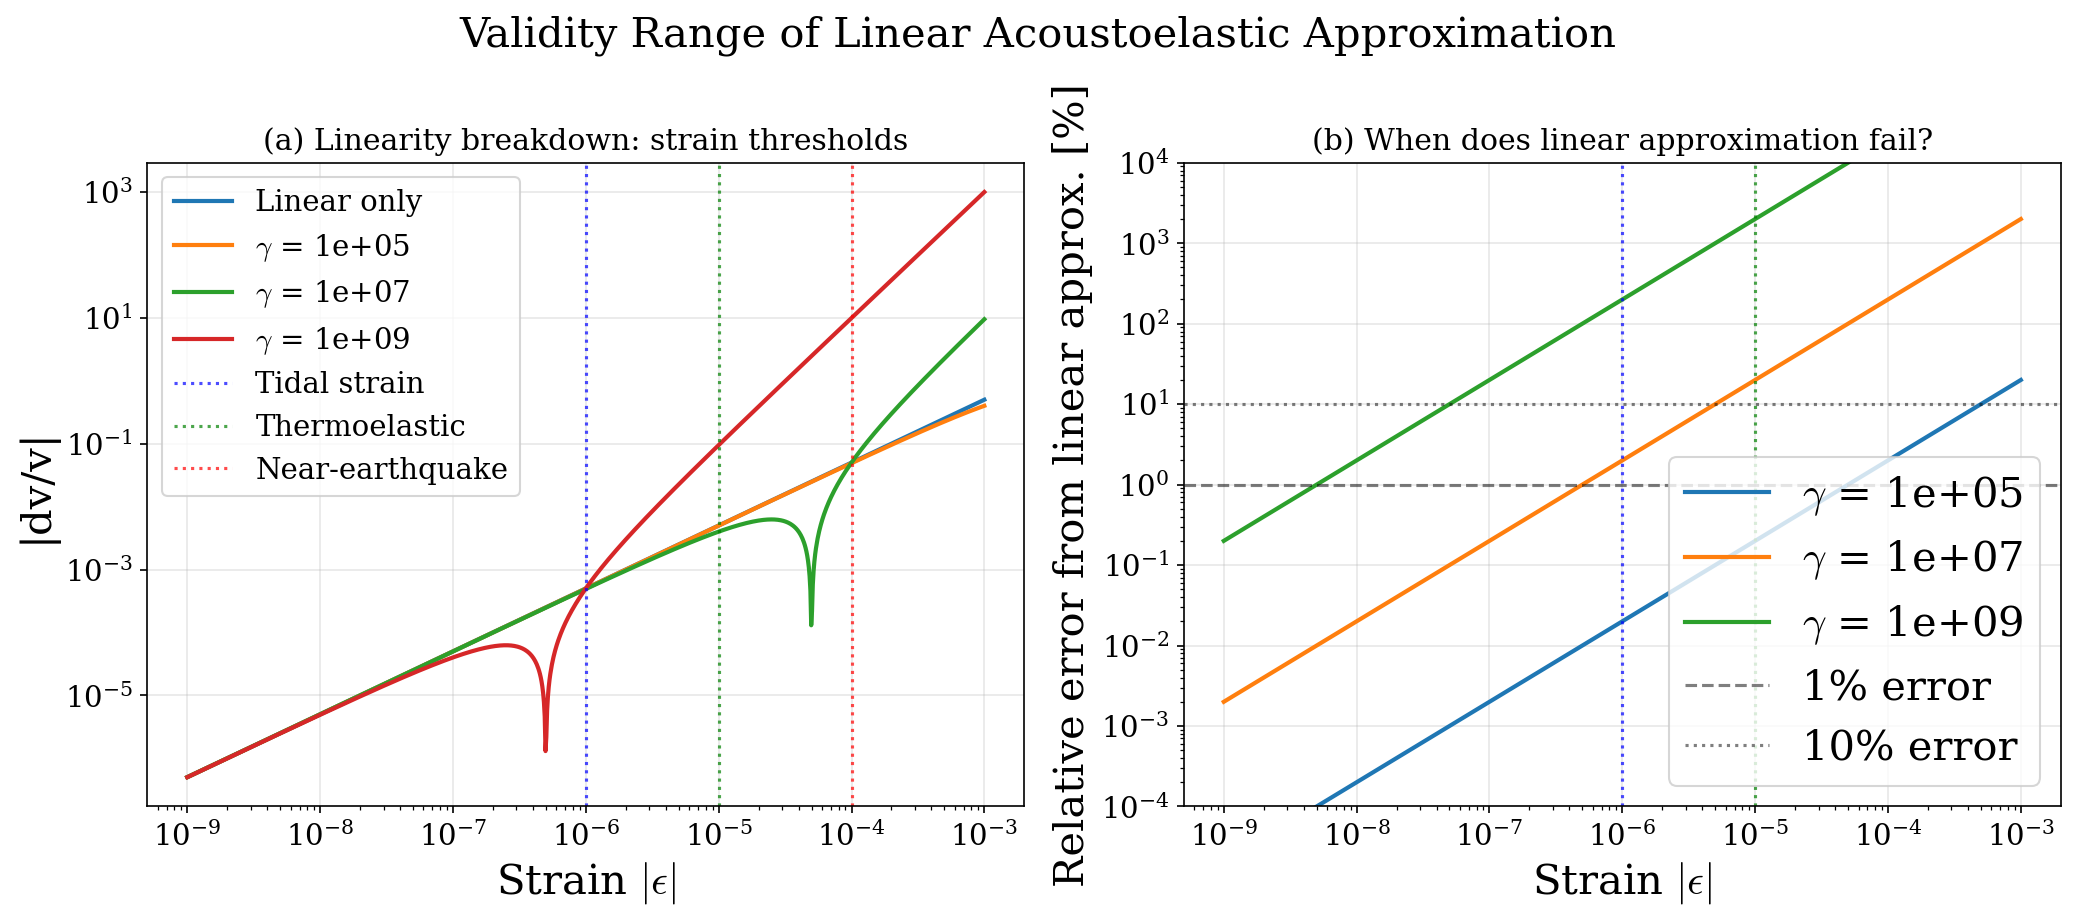

Summary of strain regimes:
  Tidal:          ~50 nanostrain  → linear approximation excellent
  Thermoelastic:  ~1-10 microstrain → linear usually valid
  Hydrological:   ~1-50 microstrain → depends on material
  Coseismic:      ~100+ microstrain → nonlinear effects important
  Strong shaking: ~1000+ microstrain → damage, slow dynamics


In [3]:
# === Validity of Linear Acoustoelastic Approximation ===

def dvv_exact_nonlinear(epsilon, beta, gamma=0, delta=0):
    """
    dv/v including higher-order terms:
    dv/v = beta*eps + gamma*eps^2 + delta*eps^3
    """
    return beta * epsilon + gamma * epsilon**2 + delta * epsilon**3

epsilon_range = np.logspace(-9, -3, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# set axis and labels fontsize to 20
for ax in axes:
    ax.tick_params(labelsize=14)
    ax.xaxis.label.set_size(20)
    ax.yaxis.label.set_size(20)

# Panel (a): dv/v for different nonlinear orders
ax = axes[0]
beta = -500
gamma_vals = [0, 1e5, 1e7, 1e9]
for gamma in gamma_vals:
    dvv_pos = dvv_exact_nonlinear(epsilon_range, beta, gamma)
    dvv_neg = dvv_exact_nonlinear(-epsilon_range, beta, gamma)
    ax.loglog(epsilon_range, np.abs(dvv_pos), lw=2, 
              label=f'$\\gamma$ = {gamma:.0e}' if gamma > 0 else 'Linear only')

ax.axvline(1e-6, color='blue', ls=':', alpha=0.7, label='Tidal strain')
ax.axvline(1e-5, color='green', ls=':', alpha=0.7, label='Thermoelastic')
ax.axvline(1e-4, color='red', ls=':', alpha=0.7, label='Near-earthquake')
ax.set_xlabel('Strain $|\\epsilon|$')
ax.set_ylabel('|dv/v|')
ax.set_title('(a) Linearity breakdown: strain thresholds')
ax.legend(fontsize=14)

# Panel (b): Relative error from linear approximation
ax = axes[1]
for gamma in [1e5, 1e7, 1e9]:
    dvv_full = dvv_exact_nonlinear(epsilon_range, beta, gamma)
    dvv_linear = beta * epsilon_range
    rel_error = np.abs((dvv_full - dvv_linear) / dvv_linear) * 100
    ax.loglog(epsilon_range, rel_error, lw=2, label=f'$\\gamma$ = {gamma:.0e}')

ax.axhline(1, color='k', ls='--', alpha=0.5, label='1% error')
ax.axhline(10, color='k', ls=':', alpha=0.5, label='10% error')
ax.axvline(1e-6, color='blue', ls=':', alpha=0.7)
ax.axvline(1e-5, color='green', ls=':', alpha=0.7)
ax.set_xlabel('Strain $|\\epsilon|$')
ax.set_ylabel('Relative error from linear approx. [%]')
ax.set_title('(b) When does linear approximation fail?')
ax.legend(fontsize=20)
ax.set_ylim(1e-4, 1e4)

fig.suptitle('Validity Range of Linear Acoustoelastic Approximation', fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('../figures/notebooks/fig16_linearity_validity.png', bbox_inches='tight')
plt.show()

print("Summary of strain regimes:")
print("  Tidal:          ~50 nanostrain  → linear approximation excellent")
print("  Thermoelastic:  ~1-10 microstrain → linear usually valid")
print("  Hydrological:   ~1-50 microstrain → depends on material")
print("  Coseismic:      ~100+ microstrain → nonlinear effects important")
print("  Strong shaking: ~1000+ microstrain → damage, slow dynamics")


## 3. Comprehensive Parameter Map

Here we synthesize the key parameters and their typical ranges across different
geological settings and applications.


In [ ]:
# === Comprehensive Parameter Overview ===

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.7, 'Parameter Ranges & Validity Conditions for dv/v Models',
        ha='center', fontsize=18, fontweight='bold')

# Table content
headers = ['Parameter', 'Symbol', 'Typical Range', 'Critical For', 'Validity Limit']
data = [
    ['Thermal diffusivity', '$\\kappa_T$', '0.15–2.0 mm²/s', 'Thermoelastic', 'Layered media'],
    ['Hydraulic diffusivity', 'c', '0.001–10 m²/s', 'Hydrological', 'Heterogeneous k'],
    ['Poissons ratio', '$\\nu$', '0.15–0.35', 'Stress partitioning', 'Anisotropy'],
    ['Undrained $\\nu$', '$\\nu_u$', '0.3–0.5', 'Poroelastic', 'Partial saturation'],
    ['Skempton coeff.', 'B', '0.2–1.0', 'Pore pressure', 'Depth-dependent'],
    ['Acoustoelastic $\\beta$', '$\\beta$', '−10 to −10⁴', 'dv/v amplitude', 'ε > 10⁻⁵'],
    ['TOE constants', 'l, m, n', '−10¹⁰ to −10¹²', 'Nonlinear response', 'Material-specific'],
    ['Shear-mod. P-deriv.', "$\\mu'=d\\mu/dP$", '5–50', 'Fokker/T&T dv/v', 'Consolidation'],
    ['Stress sensitivity', '$S_\\sigma=\\partial(\\rho v^2)/\\partial\\sigma_c$', '50–1000', 'Thermoelastic $s_T$', 'Confining P'],
    ['Thermal expansion', '$\\alpha$', '5–15 × 10⁻⁶ K⁻¹', 'Thermoelastic', 'Temperature range'],
    ['Porosity', '$\\phi$', '0.01–0.40', 'Pore pressure', 'Dual porosity'],
    ['Crack density', '$\\epsilon_c$', '0–0.2', 'Anisotropy', 'Percolation'],
    ['Healing $\\tau_{min}$', '$\\tau_{min}$', '0.01–5 yr', 'Post-seismic', 'Slow dynamics'],
    ['Healing $\\tau_{max}$', '$\\tau_{max}$', '1–30,000 yr', 'Long-term trend', 'Data duration'],
]

y_start = 9.0
row_height = 0.52
col_positions = [0.2, 2.5, 4.3, 6.5, 8.3]

# Headers
for j, (header, xpos) in enumerate(zip(headers, col_positions)):
    ax.text(xpos, y_start, header, fontsize=14, fontweight='bold',
            va='center')

# Separator line
ax.plot([0.1, 9.9], [y_start - 0.25, y_start - 0.25], 'k-', lw=1)

# Data rows
for i, row in enumerate(data):
    y = y_start - 0.25 - (i + 1) * row_height
    bg_color = '#f0f0f0' if i % 2 == 0 else 'white'
    rect = plt.Rectangle((0.1, y - 0.2), 9.8, row_height, 
                          facecolor=bg_color, edgecolor='none')
    ax.add_patch(rect)
    for j, (val, xpos) in enumerate(zip(row, col_positions)):
        ax.text(xpos, y, val, fontsize=20, va='center')

plt.tight_layout()
plt.savefig('../figures/notebooks/fig17_parameter_table.png', bbox_inches='tight')
plt.show()


## 4. Application Scenarios: Where Does Each Model Dominate?


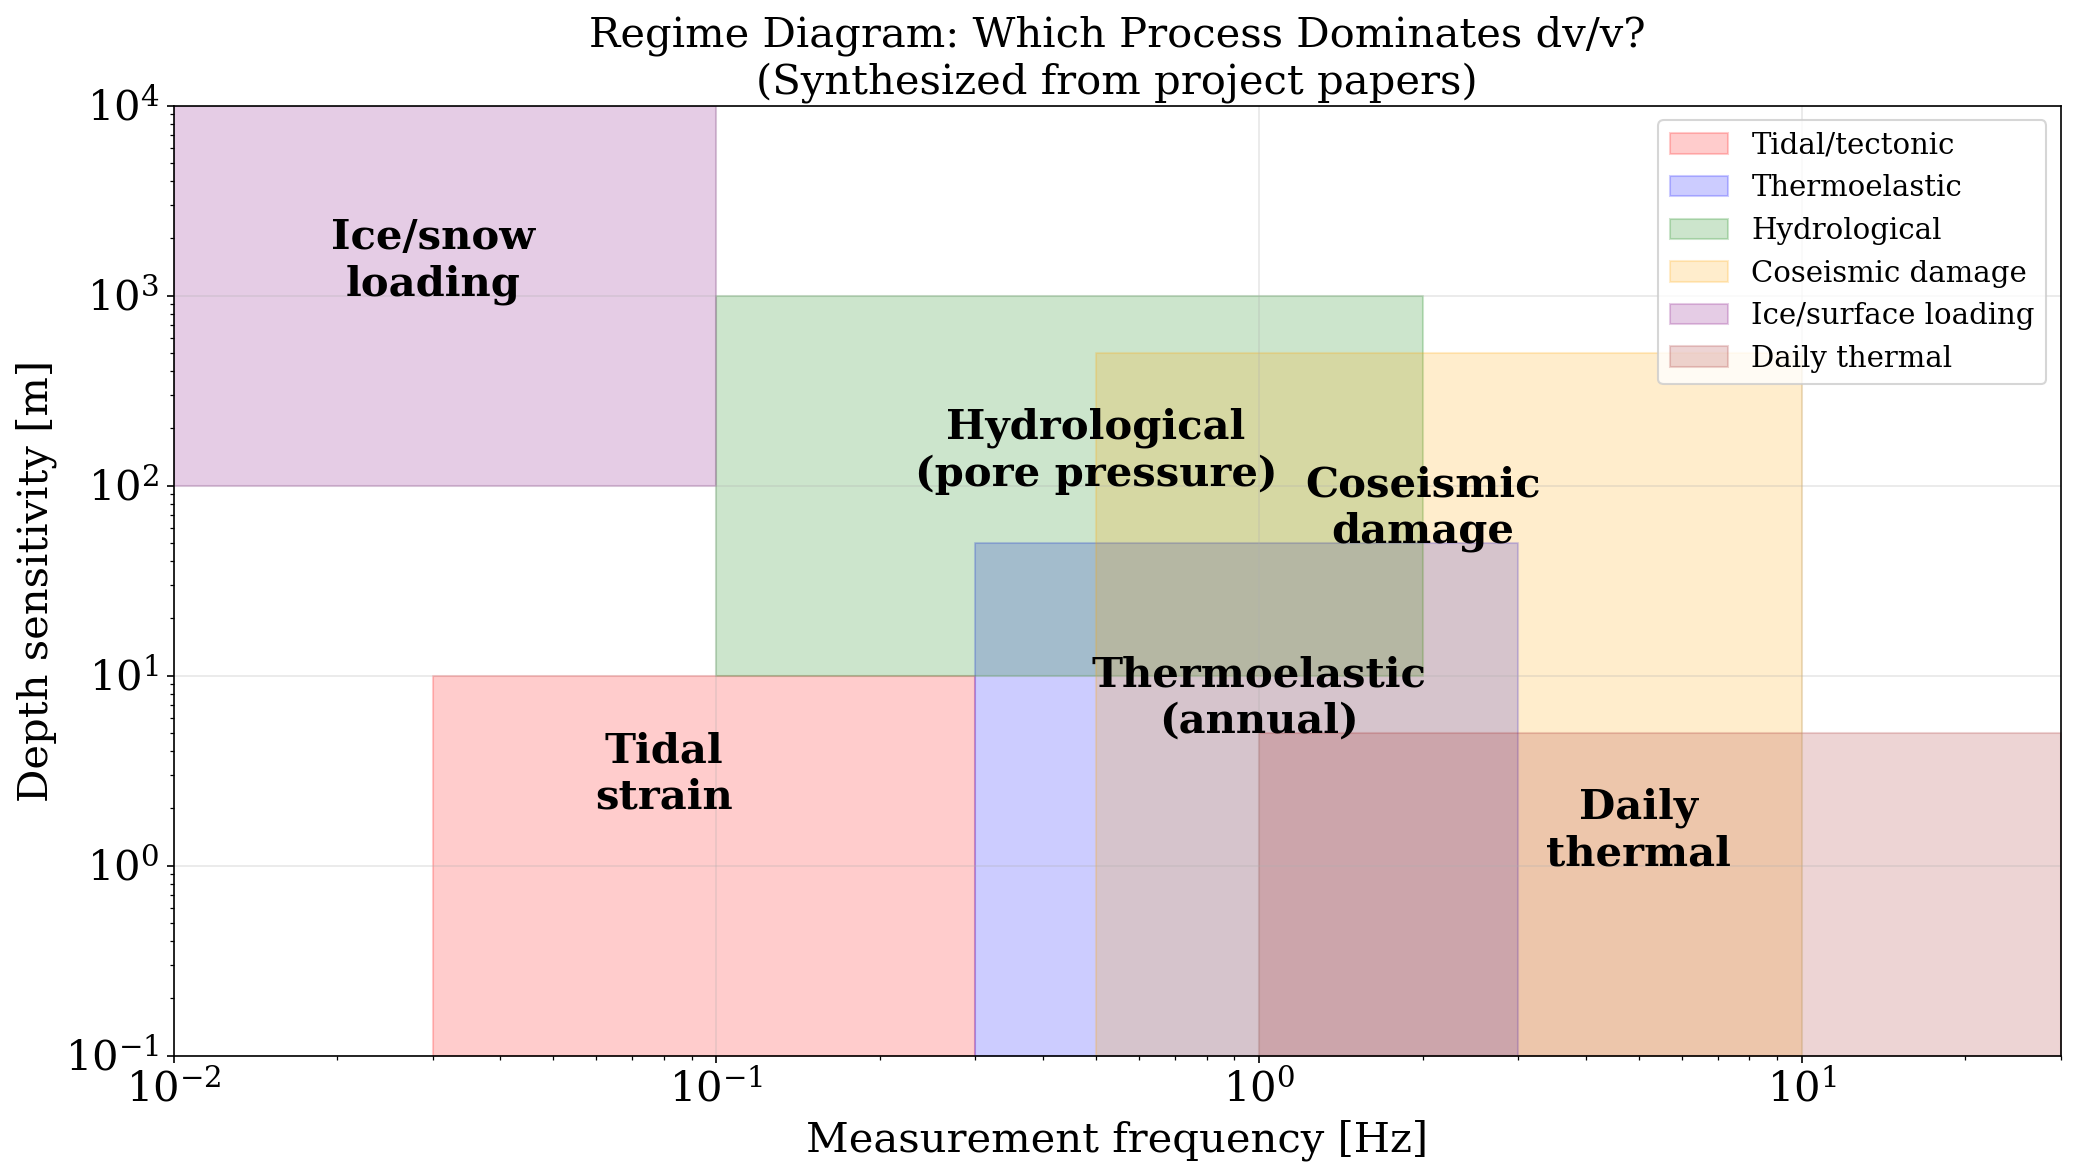


=== Summary of Model Applicability ===
Thermoelastic: Best at f > 0.5 Hz, shallow (<10 m), arid environments
Hydrological:  Best at f = 0.1-2 Hz, 10-500 m depth, wet climates
Tectonic:      Best at f < 0.5 Hz, deep, near active faults
Ice loading:   Best at f < 0.1 Hz, very deep, glaciated regions
Coseismic:     All frequencies, near-fault, transient signal


In [5]:
# === Regime diagram ===

fig, ax = plt.subplots(figsize=(14, 8))
# set axis fontsize to 20
ax.tick_params(axis='both', which='major', labelsize=20)
# set axis labels fontsize to 20
ax.set_xlabel('Measurement frequency [Hz]', fontsize=20)
ax.set_ylabel('Depth sensitivity [m]', fontsize=20)
# Create regime diagram: Frequency vs Depth
freq = np.logspace(-1.5, 1.5, 100)
depth = np.logspace(-1, 4, 100)
F, D = np.meshgrid(freq, depth)

# Define rough boundaries
ax.fill_between([0.03, 0.3], 0.1, 10, alpha=0.2, color='red', label='Tidal/tectonic')
ax.fill_between([0.3, 3], 0.1, 50, alpha=0.2, color='blue', label='Thermoelastic')
ax.fill_between([0.1, 2], 10, 1000, alpha=0.2, color='green', label='Hydrological')
ax.fill_between([0.5, 10], 0.1, 500, alpha=0.2, color='orange', label='Coseismic damage')
ax.fill_between([0.01, 0.1], 100, 10000, alpha=0.2, color='purple', label='Ice/surface loading')
ax.fill_between([1, 30], 0.1, 5, alpha=0.2, color='brown', label='Daily thermal')

# Add labels
ax.text(0.08, 2, 'Tidal\nstrain', fontsize=20, ha='center', fontweight='bold')
ax.text(1.0, 5, 'Thermoelastic\n(annual)', fontsize=20, ha='center', fontweight='bold')
ax.text(0.5, 100, 'Hydrological\n(pore pressure)', fontsize=20, ha='center', fontweight='bold')
ax.text(2.0, 50, 'Coseismic\ndamage', fontsize=20, ha='center', fontweight='bold')
ax.text(0.03, 1000, 'Ice/snow\nloading', fontsize=20, ha='center', fontweight='bold')
ax.text(5, 1, 'Daily\nthermal', fontsize=20, ha='center', fontweight='bold')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Measurement frequency [Hz]', fontsize=20)
ax.set_ylabel('Depth sensitivity [m]', fontsize=20)
ax.set_title('Regime Diagram: Which Process Dominates dv/v?\n'
             '(Synthesized from project papers)', fontsize=20)
ax.legend(loc='upper right', fontsize=14)
ax.set_xlim(0.01, 30)
ax.set_ylim(0.1, 10000)

plt.tight_layout()
plt.savefig('../figures/notebooks/fig18_regime_diagram.png', bbox_inches='tight')
plt.show()

print("\n=== Summary of Model Applicability ===")
print("Thermoelastic: Best at f > 0.5 Hz, shallow (<10 m), arid environments")
print("Hydrological:  Best at f = 0.1-2 Hz, 10-500 m depth, wet climates")  
print("Tectonic:      Best at f < 0.5 Hz, deep, near active faults")
print("Ice loading:   Best at f < 0.1 Hz, very deep, glaciated regions")
print("Coseismic:     All frequencies, near-fault, transient signal")


## Summary

This notebook suite has developed the theoretical and computational framework for interpreting
dv/v observations in terms of environmental, tectonic, and volcanic processes. Key takeaways:

1. **Thermoelastic effects** dominate at shallow depths in arid environments, with annual dv/v
   amplitudes of 0.01–0.3% depending on material properties.

2. **Hydrological loading** produces competing effects: surface loading increases velocity while 
   pore pressure decreases it. The balance depends on permeability and drainage.

3. **Nonlinear elasticity** (Murnaghan framework) provides the physical link between strain and 
   velocity change through the acoustoelastic parameter β.

4. **Stress-induced anisotropy** explains why dv/v correlates with contractional strain but not
   dilatation — oriented microcracks respond to deviatoric stress.

5. **Rheological diagnostics** from dv/v–strain crossplots can distinguish elastic, viscoelastic,
   and slow-dynamics behavior.

6. **Validity ranges** must be carefully assessed: homogeneous half-space assumptions fail for 
   strongly layered media, and linear acoustoelasticity breaks down at strains above ~10⁻⁵.
